# Image Captioning

This notebook belongs to **AISTER Step 2 (Image-based analysis)** and generates plain-text captions for all input images for downstream tag extraction.

Prepared by **Web2Learn** for the **AISTER - Krovets collection** project (2026-03-26).

**Inputs and outputs**
- Source images come from Europeana records of the Krovets collection and are downloaded with `01_download_images_from_collection.ipynb`.
- Input: downloaded image files (JPEG) from the image download notebook.
- Output: `captions.csv` with one generated caption per image (used by `03_tag_extraction.ipynb`).

**How to run**
1. Run this notebook sequentially from top to bottom.
2. In the `Configuration` cell, set the values for your environment before you continue to model loading.

## Setup

Install required dependencies.

In [1]:
!pip install -U "transformers>=5.2.0" accelerate "pillow<12" matplotlib

## Imports

Import all libraries used in this notebook.

In [2]:
from pathlib import Path
from typing import Dict, List, Union

import csv
import time

import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

from google.colab import drive

Mount your Google Drive to access images.

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

Set all user-editable constants in the next code cell before running the notebook.

This includes model settings, memory/device options, prompt text, and input/output paths.

In [5]:
MODEL_NAME = "Qwen/Qwen3-VL-2B-Instruct"

# Strategy for placing model layers on available hardware.
# "auto" lets Transformers split layers across GPU/CPU automatically.
DEVICE_MAP = "auto"

# Memory budget for automatic placement during model loading.
# Reduce these if you hit OOM, increase them only if your hardware allows it.
GPU_MAX_MEMORY = "14GiB"  # max VRAM to use on GPU 0
CPU_MAX_MEMORY = "12GiB"  # max system RAM fallback for offloaded weights

PROMPT = """
You are analysing a cultural heritage image for metadata enrichment.

Describe only what is clearly visible in the image.

Rules:
Do not guess identities, historical periods, artistic styles, materials, or techniques.
Do not interpret cultural meaning beyond what is visually obvious.
Mention: visible people/figures, visible objects, what they are doing (if clear), the setting/background, any visible text, and any visible physical damage.
If something is unclear, say "uncertain".
Keep the description concise (maximum 90 words).
Return plain text only. No markdown.
"""

# Upper bound for generated caption length.
MAX_NEW_TOKENS = 520

# Input/output paths for batch captioning.
IMAGES_DIR = "/content/drive/MyDrive/W2L/Projects/AISTER/w2l/step 2/data/folk_images/"
CAPTIONS_CSV = "/content/drive/MyDrive/W2L/Projects/AISTER/w2l/step 2/outputs/captions.csv"

## Model

Load the model and processor, and set the prompt.

In [6]:
# Set a fixed seed for reproducible model behavior across runs.
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Load the vision-language model with the selected precision/device settings.
# Constants are configured in the Configuration cell above.
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map=DEVICE_MAP,
    # Use PyTorch scaled dot-product attention (SDPA) for faster/more memory-efficient inference.
    attn_implementation="sdpa",
    max_memory={0: GPU_MAX_MEMORY, "cpu": CPU_MAX_MEMORY} if torch.cuda.is_available() else None,
)

# Keep deterministic decoding without sampling-parameter warnings.
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

# Load the matching processor (tokenizer + image preprocessor) for this model.
processor = AutoProcessor.from_pretrained(MODEL_NAME)
if hasattr(processor, "tokenizer") and processor.tokenizer is not None:
    processor.tokenizer.padding_side = "left"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

## Captioning
Define the functions for captions generation.

In [7]:
def load_image(path: Union[str, Path]) -> Image.Image:
    """Load an image from disk as RGB."""
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    return Image.open(path).convert("RGB")

def generate_captions(
    images: list[Image.Image],
    max_new_tokens: int,
    model,
    processor,
) -> list[str]:
    """Generate captions for a list of images.

    Args:
        images: List of PIL images to caption.
        max_new_tokens: Maximum number of tokens generated per caption.
        model: Loaded vision-language model used for generation.
        processor: Matching processor (tokenizer + image preprocessor).
    """
    messages = [
        [
            {
                "role": "system",
                "content": [{"type": "text", "text": PROMPT}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {
                        "type": "text",
                        "text": "Describe only what is clearly visible.",
                    },
                ],
            },
        ]
        for img in images
    ]

    messages = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    device = next(model.parameters()).device
    inputs = processor(
        text=messages,
        images=list(images),
        padding=True,
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, output_ids)
    ]
    generated = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )
    return [g.strip() for g in generated]


### Example usage

Set `image_path` to one of your images and run the cell to generate a caption.

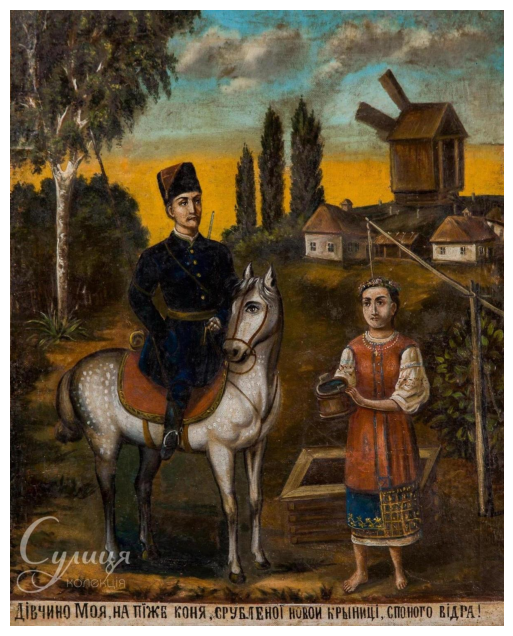


Caption: A painting depicts a man in a dark blue military uniform and a black hat, riding a white horse with a red saddle. A woman in a red and blue embroidered dress stands beside him, holding a small wooden bucket. In the background, there are houses, a windmill, trees, and a cloudy sky. The scene is set in a rural landscape. There is text at the bottom in Ukrainian: "Дівчино Моя, на піжке коня, срубленої нової кріпниці, споного відра!" and a watermark "Сушия колекція" in the lower left corner. The painting shows visible signs of age and wear.


In [11]:
# Replace this with the path to your image
image_path = "/content/drive/MyDrive/W2L/Projects/AISTER/w2l/step 2/data/folk_images/KSU19.jpg"
image = load_image(image_path)

# Plot the image
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Caption the image
caption = generate_captions([image], MAX_NEW_TOKENS, model, processor)[0]
print(f"\nCaption: {caption}")

### Batch captioning

Caption all images in a folder and save the results in a CSV file.

In [16]:
def batch_caption(
    folder: Union[str, Path],
    output_csv: Union[str, Path],
    max_new_tokens: int = MAX_NEW_TOKENS,
    model=model,
    processor=processor,
    batch_size: int = 2,
    limit: int | None = None,
    resume: bool = True
) -> List[Dict[str, str]]:
    """Caption images in a folder and save results to CSV.

    Args:
        folder: Directory containing input images.
        output_csv: Target CSV file path for writing captions.
        max_new_tokens: Maximum number of tokens generated per caption.
        model: Loaded vision-language model used for generation.
        processor: Matching processor (tokenizer + image preprocessor).
        batch_size: Number of images processed per model call.
        limit: Optional cap on how many pending images to process in this run.
        resume: If True, skip image_ids that already exist in output_csv.
    """
    folder = Path(folder)
    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)

    processed_ids: set[str] = set()
    if resume and output_csv.exists() and output_csv.stat().st_size > 0:
        with output_csv.open("r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            processed_ids = {
                row["image_id"]
                for row in reader
                if isinstance(row.get("image_id"), str) and row["image_id"]
            }

    extensions = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
    all_paths = [
        p for p in sorted(folder.iterdir()) if p.is_file() and p.suffix.lower() in extensions
    ]
    pending_paths = [p for p in all_paths if p.stem not in processed_ids]

    if limit is not None:
        pending_paths = pending_paths[:limit]

    print(f"Found {len(all_paths)} images total.")
    if resume:
        print(f"Skipping {len(processed_ids)} already-captioned image_ids.")
    print(f"Processing {len(pending_paths)} images in this run.")

    write_header = (not output_csv.exists()) or (output_csv.stat().st_size == 0)
    new_results: List[Dict[str, str]] = []

    total = len(pending_paths)
    run_t0 = time.perf_counter()

    with output_csv.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["image_id", "caption"])
        if write_header:
            writer.writeheader()

        for start in range(0, total, batch_size):
            batch_t0 = time.perf_counter()

            batch_paths = pending_paths[start:start + batch_size]
            images = [load_image(p) for p in batch_paths]
            captions = generate_captions(
                images,
                max_new_tokens=max_new_tokens,
                model=model,
                processor=processor,
            )

            for path, caption in zip(batch_paths, captions):
                row = {"image_id": path.stem, "caption": caption}
                writer.writerow(row)
                new_results.append(row)

            f.flush()

            done = min(start + batch_size, total)
            batch_elapsed = time.perf_counter() - batch_t0
            total_elapsed = time.perf_counter() - run_t0
            last_path = batch_paths[-1]

            print(
                f"[{done}/{total}] "
                f"last={last_path.name} | "
                f"batch={batch_elapsed:.1f}s | "
                f"elapsed={total_elapsed:.1f}s"
            )

    print(f"Saved {len(new_results)} new captions to {output_csv}")
    return new_results

### Run batch captioning

In [17]:
# Paths come from the Configuration cell. Choose your own run settings below.
new_captions = batch_caption(
    folder=IMAGES_DIR,
    output_csv=CAPTIONS_CSV,
    max_new_tokens=MAX_NEW_TOKENS,
    batch_size=2,  # images per batch
    limit=4,       # max number of pending images to process this run (None = all)
    resume=True,   # skip already processed image_ids in existing CSV
)

Found 312 images total.
Skipping 0 already-captioned image_ids.
Processing 4 images in this run.
[2/4] last=HMT2.jpg | batch=8.2s | elapsed=8.2s
[4/4] last=KSU10.jpg | batch=9.1s | elapsed=17.3s
Saved 4 new captions to /content/drive/MyDrive/W2L/Projects/AISTER/w2l/step 2/outputs/captions.csv
